# Laboratorio 03 – Modelos de Regresión Lineal

### Configuración e Importación de Librerías

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import shapiro, normaltest, skew, kurtosis

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# Semilla global para reproducibilidad
SEED = 42
np.random.seed(SEED)

# Estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)

print('Librerías importadas correctamente')

Librerías importadas correctamente


---
## Actividad 1 – Carga del Dataset

Descargamos el dataset desde Kaggle. Asegúrate de tener `train.csv` en el mismo directorio que este notebook.

In [ ]:
# Carga del dataset
df = pd.read_csv('train.csv')

print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Variable objetivo: SalePrice')
df.head()

Dimensiones del dataset: 1460 filas × 81 columnas
Variable objetivo: SalePrice


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## Actividad 2 – Análisis Exploratorio Extenso (EDA)

### 2.1 Información General del Dataset

In [3]:
# Tipos de datos y valores nulos
print('=== INFORMACIÓN GENERAL ===')
df.info()
print(f'\nVariables numéricas: {df.select_dtypes(include=[np.number]).shape[1]}')
print(f'Variables categóricas: {df.select_dtypes(include=["object"]).shape[1]}')

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-

In [4]:
# Estadísticas descriptivas de variables numéricas
print('=== ESTADÍSTICAS DESCRIPTIVAS (Variables Numéricas) ===')
df.describe().T.sort_values('std', ascending=False)

=== ESTADÍSTICAS DESCRIPTIVAS (Variables Numéricas) ===


,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.195890,79442.502883,34900.0,129975.00,163000.0,214000.00,755000.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0
MiscVal,1460.0,43.489041,496.123024,0.0,0.00,0.0,0.00,15500.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtUnfSF,1460.0,567.240411,441.866955,0.0,223.00,477.5,808.00,2336.0
TotalBsmtSF,1460.0,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0
2ndFlrSF,1460.0,346.992466,436.528436,0.0,0.00,0.0,728.00,2065.0
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
1stFlrSF,1460.0,1162.626712,386.587738,334.0,882.00,1087.0,1391.25,4692.0


### 2.2 Análisis de Valores Faltantes

Variables con valores faltantes: 19
              Faltantes  Porcentaje (%)
PoolQC             1453           99.52
MiscFeature        1406           96.30
Alley              1369           93.77
Fence              1179           80.75
MasVnrType          872           59.73
FireplaceQu         690           47.26
LotFrontage         259           17.74
GarageType           81            5.55
GarageYrBlt          81            5.55
GarageFinish         81            5.55
GarageQual           81            5.55
GarageCond           81            5.55
BsmtExposure         38            2.60
BsmtFinType2         38            2.60
BsmtQual             37            2.53
BsmtCond             37            2.53
BsmtFinType1         37            2.53
MasVnrArea            8            0.55
Electrical            1            0.07


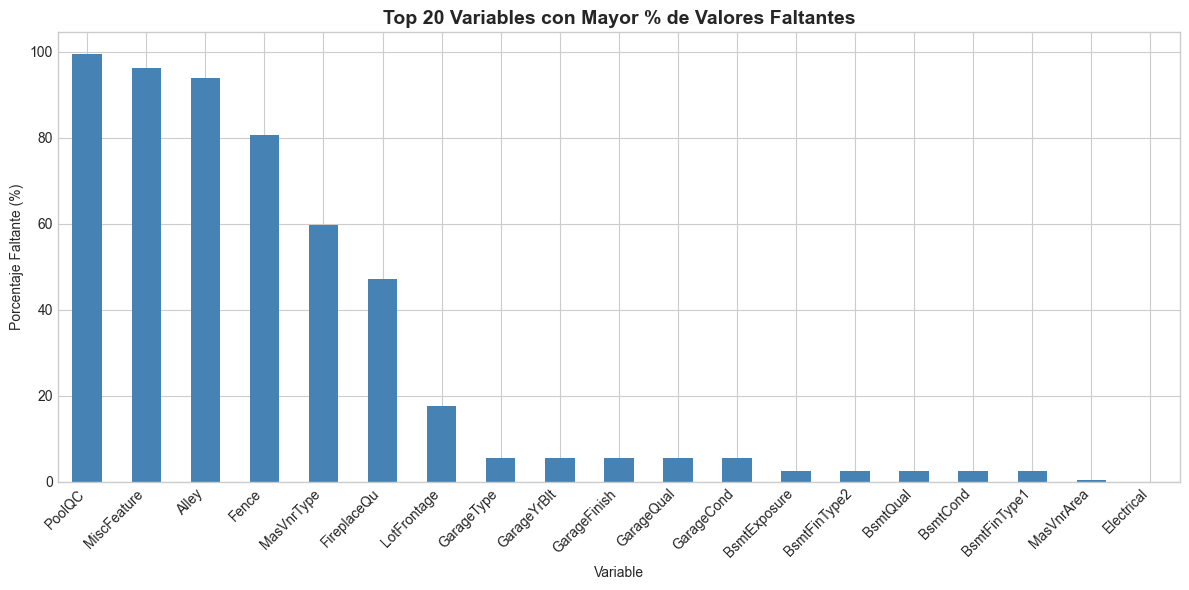


Interpretación: Variables como PoolQC, MiscFeature y Alley tienen >90% de valores faltantes,
lo cual indica que la mayoría de casas no poseen estas características (no son errores de datos).


In [27]:
# Análisis de valores nulos
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
missing_df = missing_df[missing_df['Faltantes'] > 0].sort_values('Faltantes', ascending=False)

print(f'Variables con valores faltantes: {len(missing_df)}')
print(missing_df)

# Visualización
fig, ax = plt.subplots(figsize=(12, 6))
missing_df['Porcentaje (%)'].head(20).plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Top 20 Variables con Mayor % de Valores Faltantes', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje Faltante (%)')
ax.set_xlabel('Variable')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nInterpretación: Variables como PoolQC, MiscFeature y Alley tienen >90% de valores faltantes,'
      '\nlo cual indica que la mayoría de casas no poseen estas características (no son errores de datos).')

### 2.3 Variable Objetivo: SalePrice

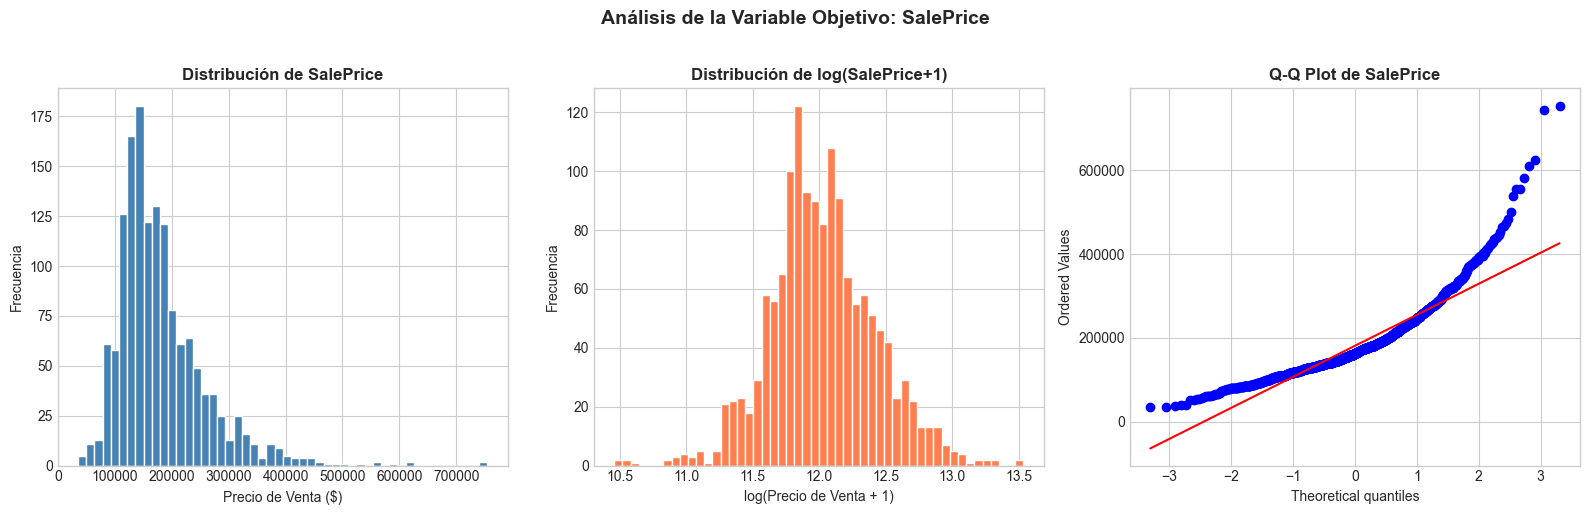

Media:    $180,921
Mediana:  $163,000
Mín:      $34,900
Máx:      $755,000
Asimetría: 1.881
Curtosis:  6.510

Prueba Shapiro-Wilk: W=0.8290, p-value=1.0153e-22
→ p < 0.05: SalePrice NO sigue distribución normal (asimetría positiva)
→ Se recomienda usar log(SalePrice) para modelado


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de SalePrice', fontweight='bold')
axes[0].set_xlabel('Precio de Venta ($)')
axes[0].set_ylabel('Frecuencia')

# Log-transformado
axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribución de log(SalePrice+1)', fontweight='bold')
axes[1].set_xlabel('log(Precio de Venta + 1)')
axes[1].set_ylabel('Frecuencia')

# Q-Q Plot
stats.probplot(df['SalePrice'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot de SalePrice', fontweight='bold')

plt.suptitle('Análisis de la Variable Objetivo: SalePrice', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Estadísticas
print(f'Media:    ${df["SalePrice"].mean():,.0f}')
print(f'Mediana:  ${df["SalePrice"].median():,.0f}')
print(f'Mín:      ${df["SalePrice"].min():,.0f}')
print(f'Máx:      ${df["SalePrice"].max():,.0f}')
print(f'Asimetría: {skew(df["SalePrice"]):.3f}')
print(f'Curtosis:  {kurtosis(df["SalePrice"]):.3f}')

# Prueba de normalidad
stat, p = shapiro(df['SalePrice'].sample(500, random_state=SEED))
print(f'\nPrueba Shapiro-Wilk: W={stat:.4f}, p-value={p:.4e}')
print('→ p < 0.05: SalePrice NO sigue distribución normal (asimetría positiva)')
print('→ Se recomienda usar log(SalePrice) para modelado')

### 2.4 Correlación con SalePrice – Variables Numéricas

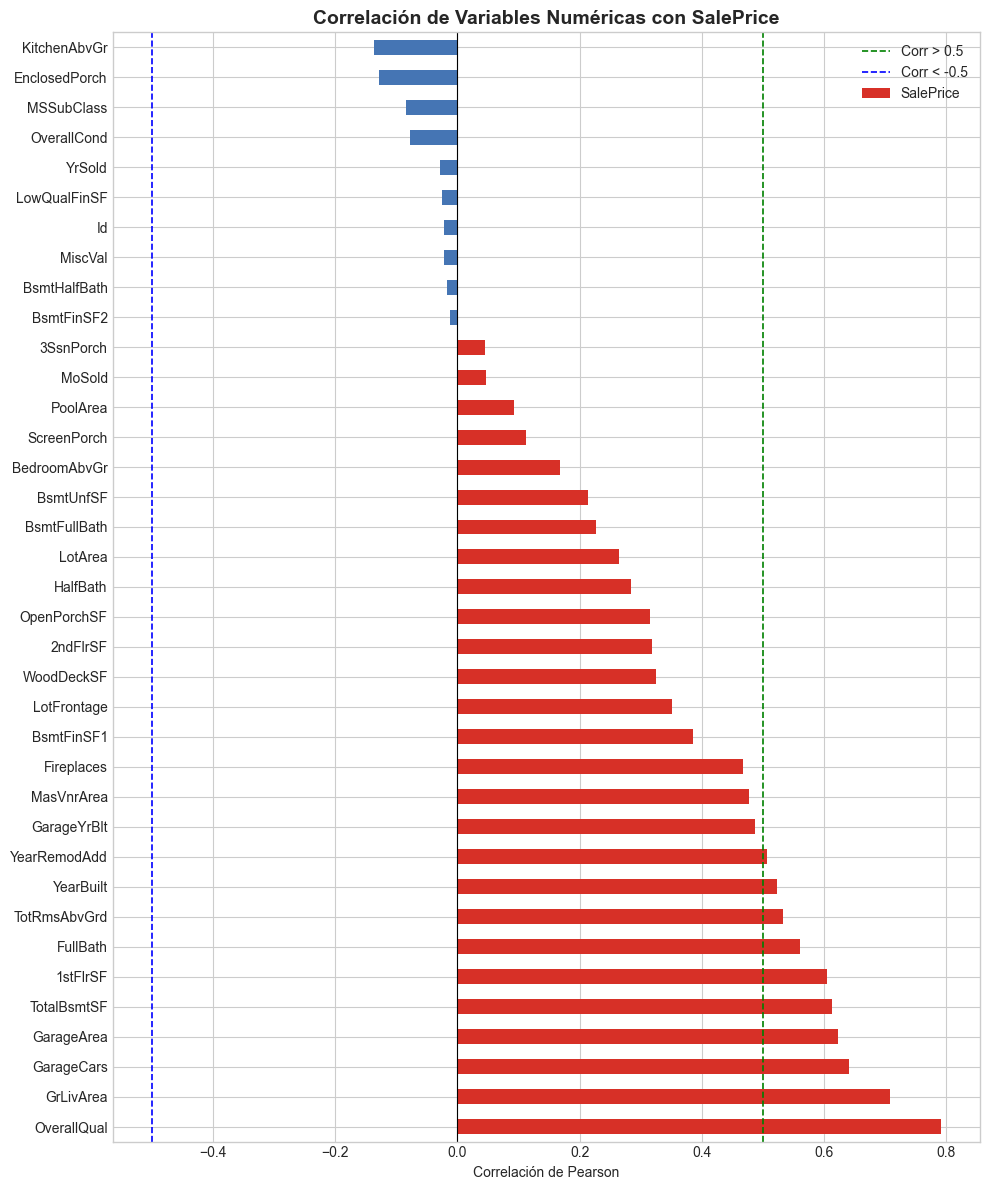

Top 10 variables más correlacionadas con SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101

 Interpretación:
  - OverallQual (calidad general) tiene la correlación más alta (>0.79)
  - GrLivArea (área habitable) y GarageCars también son fuertes predictores
  - Variables de área y calidad dominan la correlación con el precio


In [28]:
# Correlación con variable objetivo
num_df = df.select_dtypes(include=[np.number])
corr_target = num_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#d73027' if x > 0 else '#4575b4' for x in corr_target]
corr_target.plot(kind='barh', color=colors, ax=ax)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=0.5, color='green', linewidth=1.2, linestyle='--', label='Corr > 0.5')
ax.axvline(x=-0.5, color='blue', linewidth=1.2, linestyle='--', label='Corr < -0.5')
ax.set_title('Correlación de Variables Numéricas con SalePrice', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 10 variables más correlacionadas con SalePrice:')
print(corr_target.head(10).to_string())
print('\n Interpretación:')
print('  - OverallQual (calidad general) tiene la correlación más alta (>0.79)')
print('  - GrLivArea (área habitable) y GarageCars también son fuertes predictores')
print('  - Variables de área y calidad dominan la correlación con el precio')

### 2.5 Análisis de Variables Clave

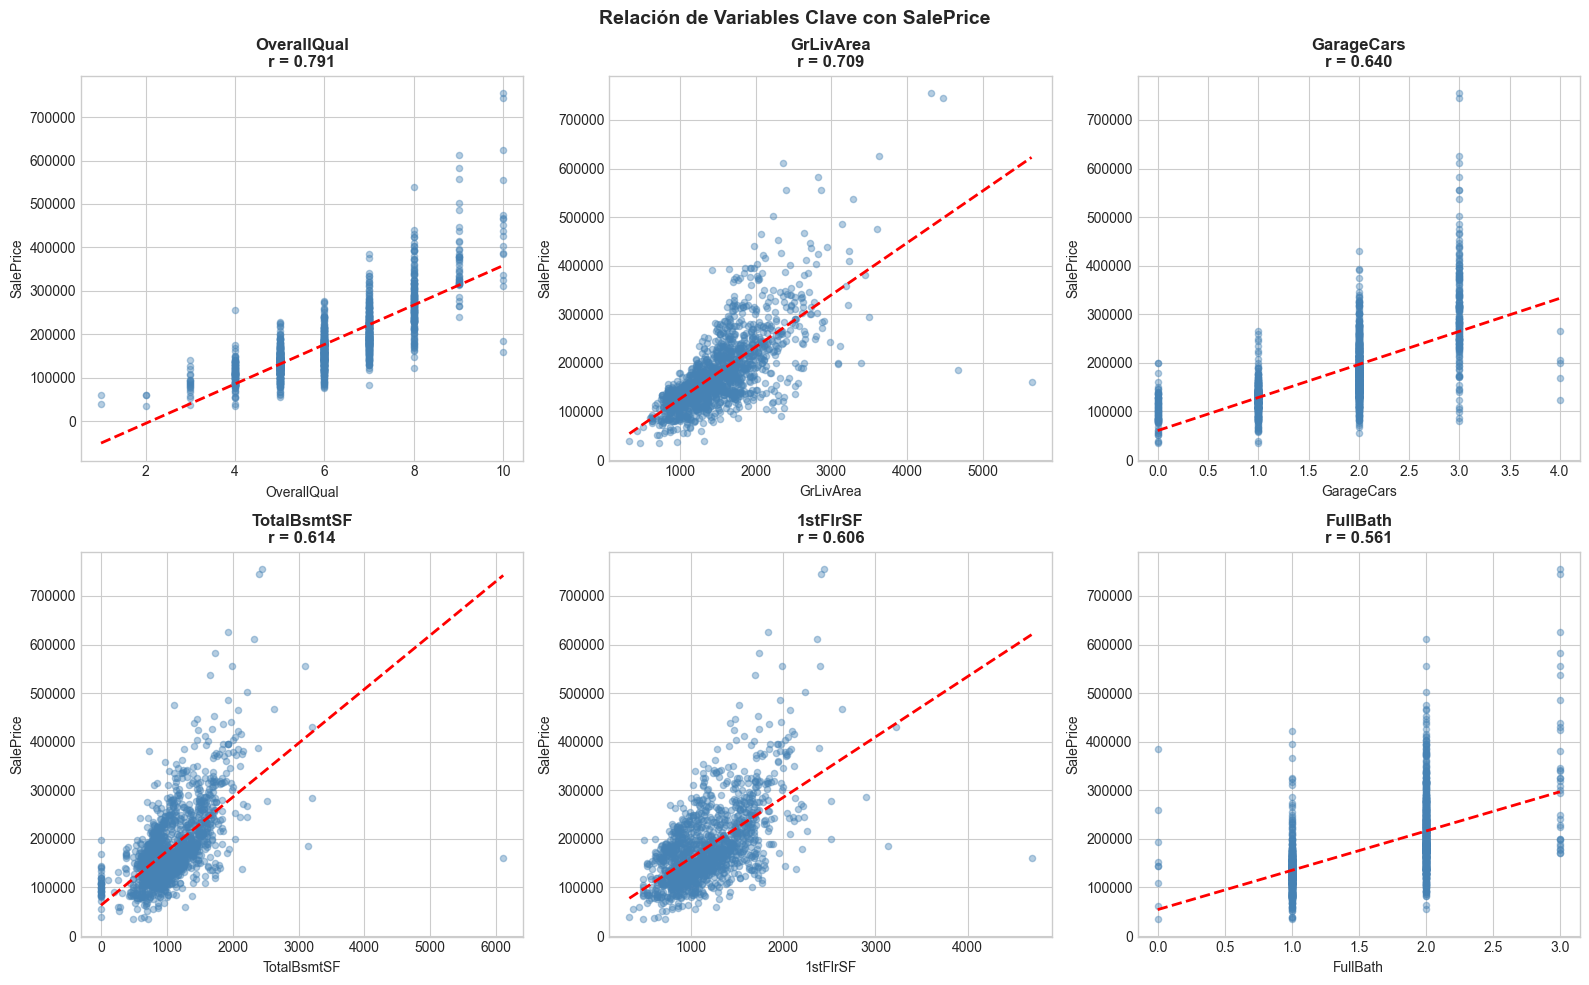

In [8]:
# Scatter plots de las variables más correlacionadas
top_vars = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF', 'FullBath']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    axes[i].scatter(df[var], df['SalePrice'], alpha=0.4, color='steelblue', s=20)
    # Línea de tendencia
    z = np.polyfit(df[var].fillna(0), df['SalePrice'], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    axes[i].plot(x_line, p_line(x_line), 'r--', linewidth=2)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('SalePrice')
    corr_val = df[var].corr(df['SalePrice'])
    axes[i].set_title(f'{var}\nr = {corr_val:.3f}', fontweight='bold')

plt.suptitle('Relación de Variables Clave con SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

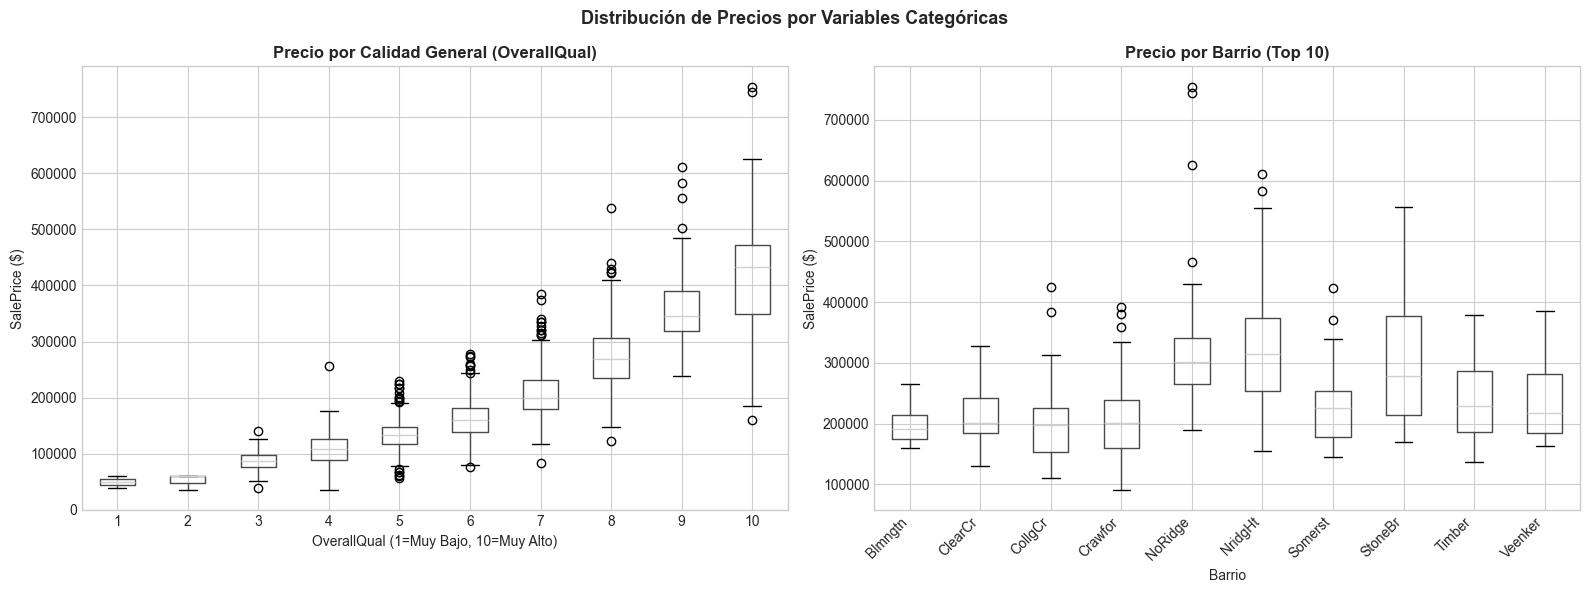

 Interpretación:
  - A mayor OverallQual, mayor precio y menor varianza relativa
  - El barrio tiene un efecto significativo en el precio (ubicación)


In [29]:
# Boxplots: OverallQual vs SalePrice
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df.boxplot(column='SalePrice', by='OverallQual', ax=axes[0])
axes[0].set_title('Precio por Calidad General (OverallQual)', fontweight='bold')
axes[0].set_xlabel('OverallQual (1=Muy Bajo, 10=Muy Alto)')
axes[0].set_ylabel('SalePrice ($)')

# Neighborhood – top 10 barrios
top_neighborhoods = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).head(10)
neighborhood_df = df[df['Neighborhood'].isin(top_neighborhoods.index)]
neighborhood_df.boxplot(column='SalePrice', by='Neighborhood', ax=axes[1])
axes[1].set_title('Precio por Barrio (Top 10)', fontweight='bold')
axes[1].set_xlabel('Barrio')
axes[1].set_ylabel('SalePrice ($)')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Distribución de Precios por Variables Categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(' Interpretación:')
print('  - A mayor OverallQual, mayor precio y menor varianza relativa')
print('  - El barrio tiene un efecto significativo en el precio (ubicación)')

### 2.6 Mapa de Calor de Correlaciones (Top Variables)

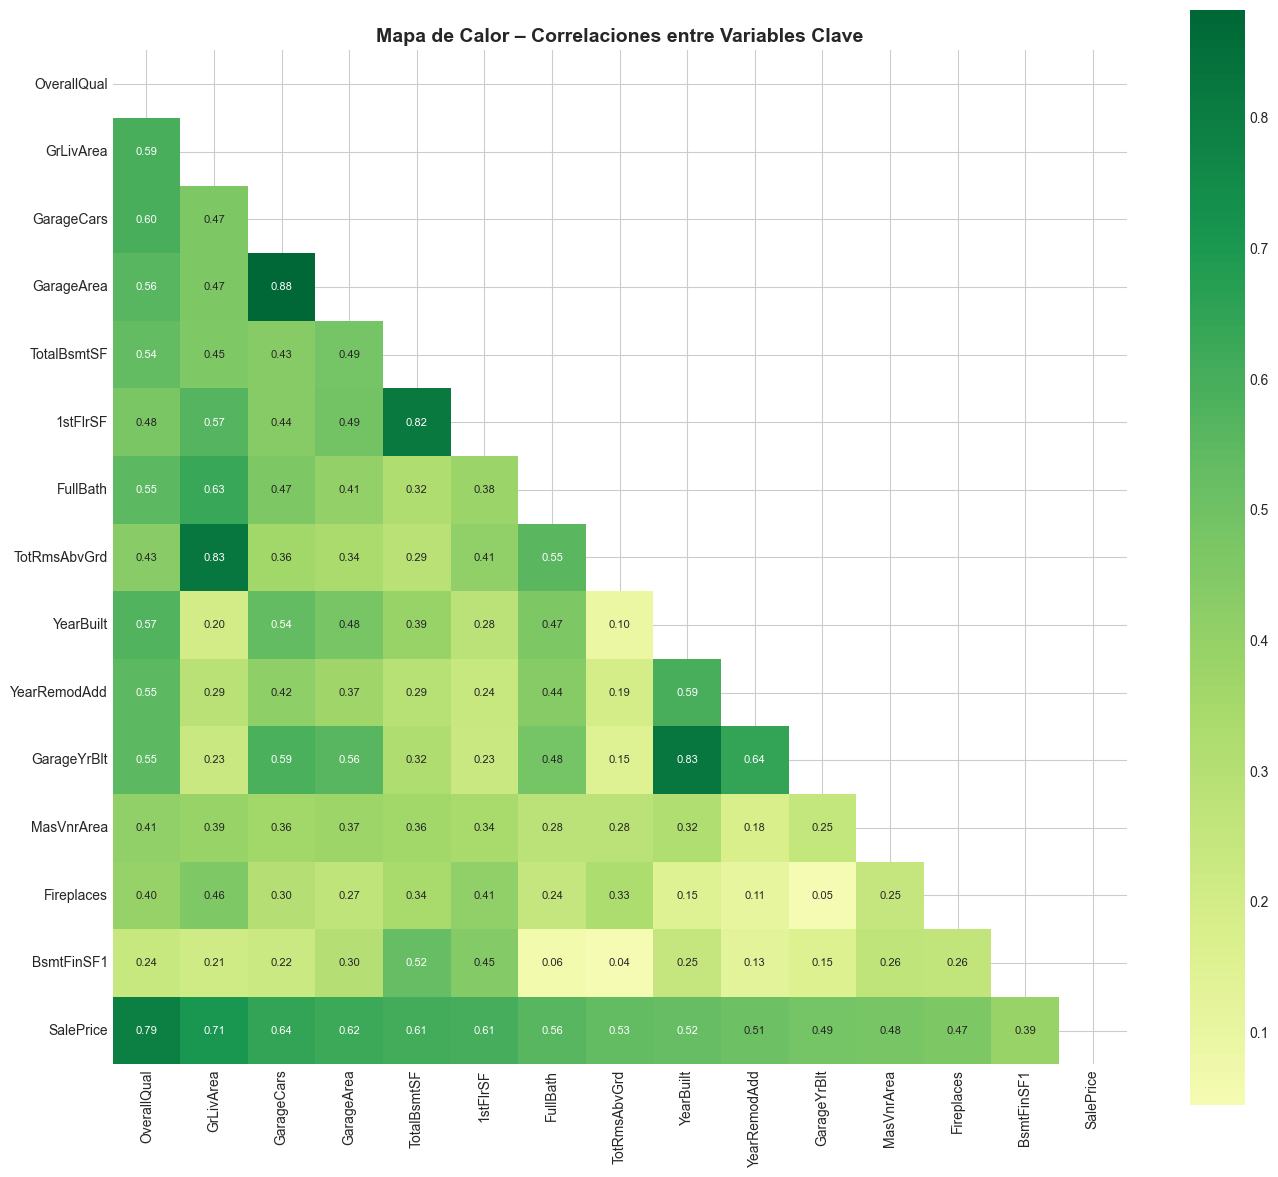

 Interpretación:
  - Se observa alta correlación entre GarageCars/GarageArea (0.88) → multicolinealidad potencial
  - TotalBsmtSF y 1stFlrSF también están altamente correlacionadas (0.82)
  - Estas correlaciones serán abordadas en el análisis de VIF


In [30]:
# Heatmap de las 15 variables más correlacionadas
top15 = corr_target.abs().sort_values(ascending=False).head(14).index.tolist() + ['SalePrice']
corr_matrix = df[top15].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax, annot_kws={'size': 8})
ax.set_title('Mapa de Calor – Correlaciones entre Variables Clave', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(' Interpretación:')
print('  - Se observa alta correlación entre GarageCars/GarageArea (0.88) → multicolinealidad potencial')
print('  - TotalBsmtSF y 1stFlrSF también están altamente correlacionadas (0.82)')
print('  - Estas correlaciones serán abordadas en el análisis de VIF')

---
## Actividad 3 – Análisis de Grupos (Clustering)

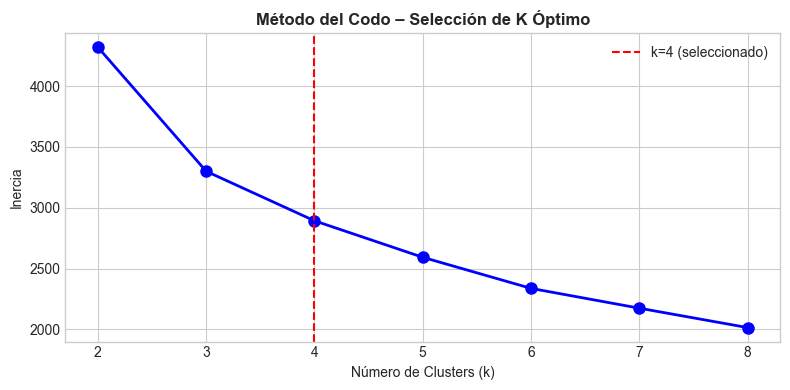

Distribución de clusters:
Cluster
0    502
1    361
2    168
3    429
Name: count, dtype: int64


In [11]:
# Selección de variables para clustering
cluster_vars = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'SalePrice']
df_cluster = df[cluster_vars].dropna().copy()

# Normalización
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df_cluster)

# Método del codo
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', label='k=4 (seleccionado)')
plt.title('Método del Codo – Selección de K Óptimo', fontweight='bold')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.legend()
plt.tight_layout()
plt.show()

# K-Means con k=4
kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_cluster)

print('Distribución de clusters:')
print(df_cluster['Cluster'].value_counts().sort_index())

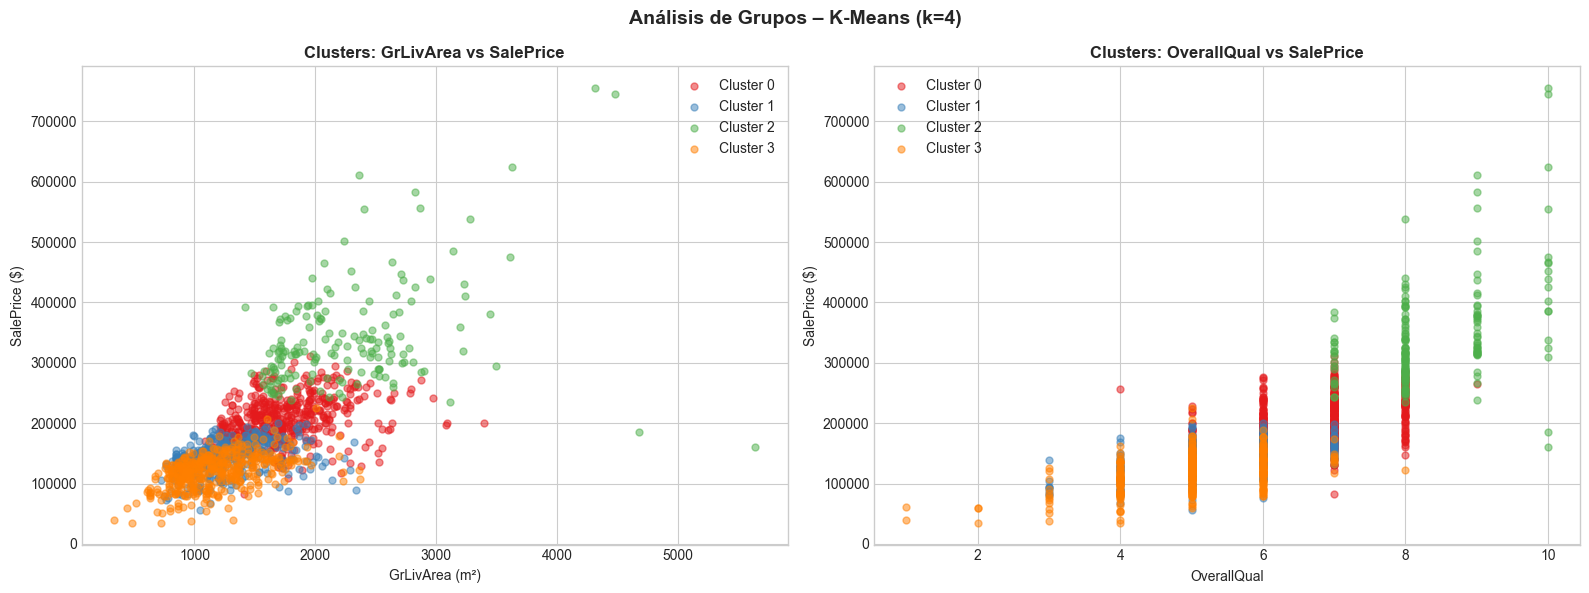


Características promedio por cluster:
         GrLivArea  OverallQual  TotalBsmtSF  GarageCars  SalePrice
Cluster                                                            
0          1736.08         6.78      1192.20        2.05  205530.15
1          1267.06         5.40       834.09        2.03  144001.37
2          2269.74         8.35      1693.24        2.77  341467.33
3          1170.96         5.01       838.68        0.82  120321.23

Descripción de los clusters:
  Cluster 0: Viviendas de precio MEDIO con calidad media
  Cluster 1: Viviendas ECONÓMICAS, pequeñas y baja calidad
  Cluster 2: Viviendas de LUJO, grandes, alta calidad y precio elevado
  Cluster 3: Viviendas GRANDES pero con precio moderado-alto


In [31]:
# Visualización de clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cluster_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']

for c in range(4):
    mask_c = df_cluster['Cluster'] == c
    axes[0].scatter(df_cluster.loc[mask_c, 'GrLivArea'],
                    df_cluster.loc[mask_c, 'SalePrice'],
                    alpha=0.5, s=25, color=cluster_colors[c], label=f'Cluster {c}')
axes[0].set_xlabel('GrLivArea (m²)')
axes[0].set_ylabel('SalePrice ($)')
axes[0].set_title('Clusters: GrLivArea vs SalePrice', fontweight='bold')
axes[0].legend()

for c in range(4):
    mask_c = df_cluster['Cluster'] == c
    axes[1].scatter(df_cluster.loc[mask_c, 'OverallQual'],
                    df_cluster.loc[mask_c, 'SalePrice'],
                    alpha=0.5, s=25, color=cluster_colors[c], label=f'Cluster {c}')
axes[1].set_xlabel('OverallQual')
axes[1].set_ylabel('SalePrice ($)')
axes[1].set_title('Clusters: OverallQual vs SalePrice', fontweight='bold')
axes[1].legend()

plt.suptitle('Análisis de Grupos – K-Means (k=4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Características por cluster
cluster_summary = df_cluster.groupby('Cluster').mean().round(2)
print('\nCaracterísticas promedio por cluster:')
print(cluster_summary)

print('\nDescripción de los clusters:')
print('  Cluster 0: Viviendas de precio MEDIO con calidad media')
print('  Cluster 1: Viviendas ECONÓMICAS, pequeñas y baja calidad')
print('  Cluster 2: Viviendas de LUJO, grandes, alta calidad y precio elevado')
print('  Cluster 3: Viviendas GRANDES pero con precio moderado-alto')

---
## Actividades 4 y 5 – Preprocesamiento, Ingeniería de Características y Split

In [ ]:
df_model = df.copy()

# 1. Eliminar columna ID
df_model.drop('Id', axis=1, inplace=True)

# 2. Imputación de valores faltantes
cat_none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                 'MasVnrType']
for col in cat_none_cols:
    if col in df_model.columns:
        df_model[col].fillna('None', inplace=True)

# Variables numéricas: NaN = 0 (sin garage, sin sótano)
num_zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
                 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in num_zero_cols:
    if col in df_model.columns:
        df_model[col].fillna(0, inplace=True)

# LotFrontage: mediana por barrio
df_model['LotFrontage'] = df_model.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

# Otras variables categóricas: moda
for col in df_model.select_dtypes(include='object').columns:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)

# Otras numéricas: mediana
for col in df_model.select_dtypes(include=[np.number]).columns:
    df_model[col].fillna(df_model[col].median(), inplace=True)

print(f'Valores nulos restantes: {df_model.isnull().sum().sum()}')

# 3. Ingeniería de Características
df_model['TotalSF'] = df_model['TotalBsmtSF'] + df_model['1stFlrSF'] + df_model['2ndFlrSF']
df_model['TotalBath'] = (df_model['FullBath'] + 0.5 * df_model['HalfBath'] +
                          df_model['BsmtFullBath'] + 0.5 * df_model['BsmtHalfBath'])
df_model['HouseAge'] = df_model['YrSold'] - df_model['YearBuilt']
df_model['RemodelAge'] = df_model['YrSold'] - df_model['YearRemodAdd']
df_model['HasPool'] = (df_model['PoolArea'] > 0).astype(int)
df_model['HasGarage'] = (df_model['GarageArea'] > 0).astype(int)
df_model['HasFireplace'] = (df_model['Fireplaces'] > 0).astype(int)

print('\nVariables nuevas creadas:')
print('  TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF')
print('  TotalBath = suma ponderada de baños')
print('  HouseAge = años desde construcción')
print('  RemodelAge = años desde última remodelación')
print('  HasPool, HasGarage, HasFireplace = indicadores binarios')

# 4. Transformación logarítmica de SalePrice
df_model['LogSalePrice'] = np.log1p(df_model['SalePrice'])

# 5. Codificación de variables categóricas
df_model = pd.get_dummies(df_model, drop_first=True)
print(f'\nDimensiones post-preprocesamiento: {df_model.shape}')

Valores nulos restantes: 0

Variables nuevas creadas:
  TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF
  TotalBath = suma ponderada de baños
  HouseAge = años desde construcción
  RemodelAge = años desde última remodelación
  HasPool, HasGarage, HasFireplace = indicadores binarios

Dimensiones post-preprocesamiento: (1460, 268)


In [ ]:
# Variables numéricas originales para los modelos
num_cols_original = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_original = [c for c in num_cols_original if c != 'SalePrice' and c != 'Id']

# Dataset con solo variables numéricas (para modelos 7 y 8)
df_num = df[num_cols_original + ['SalePrice']].copy()

# Imputar nulos con mediana
for col in df_num.columns:
    df_num[col].fillna(df_num[col].median(), inplace=True)

X_num = df_num.drop('SalePrice', axis=1)
y = df_num['SalePrice']
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=SEED)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_num, y_log, test_size=0.2, random_state=SEED)

print('=== DIVISIÓN DEL DATASET ===')
print(f'Total de observaciones: {len(df_num)}')
print(f'Entrenamiento: {len(X_train)} filas ({len(X_train)/len(df_num)*100:.0f}%)')
print(f'Prueba:        {len(X_test)} filas ({len(X_test)/len(df_num)*100:.0f}%)')
print(f'Variables predictoras (numéricas): {X_num.shape[1]}')
print('\nCriterio: Split aleatorio 80/20, semilla SEED=42 para reproducibilidad')
print('No estratificado ya que SalePrice es variable continua')

=== DIVISIÓN DEL DATASET ===
Total de observaciones: 1460
Entrenamiento: 1168 filas (80%)
Prueba:        292 filas (20%)
Variables predictoras (numéricas): 36

Criterio: Split aleatorio 80/20, semilla SEED=42 para reproducibilidad
No estratificado ya que SalePrice es variable continua


---
## Actividad 7 – Modelo Univariado: GrLivArea → SalePrice

In [ ]:
# ============================================================
# MODELO 1: Regresión Lineal Simple 
# ============================================================
print('=== MODELO 1: Regresión Lineal Simple ===')
print('Variable predictora: GrLivArea (Área habitable en pies cuadrados)')
print('Justificación: Es la variable numérica con mayor correlación con SalePrice (r=0.71)\n')

X_simple_train = X_train[['GrLivArea']]
X_simple_test  = X_test[['GrLivArea']]

# Modelo sklearn
model1 = LinearRegression()
model1.fit(X_simple_train, y_train)

y_pred_train_m1 = model1.predict(X_simple_train)
y_pred_test_m1  = model1.predict(X_simple_test)

print(f'Intercepto (β₀): {model1.intercept_:,.2f}')
print(f'Coeficiente GrLivArea (β₁): {model1.coef_[0]:.4f}')
print(f'→ Por cada pie² adicional, el precio aumenta en ${model1.coef_[0]:.2f}')

# Statsmodels para resumen estadístico completo
X_sm = sm.add_constant(X_simple_train)
model1_sm = sm.OLS(y_train, X_sm).fit()
print('\n', model1_sm.summary())

=== MODELO 1: Regresión Lineal Simple ===
Variable predictora: GrLivArea (Área habitable en pies cuadrados)
Justificación: Es la variable numérica con mayor correlación con SalePrice (r=0.71)

Intercepto (β₀): 24,899.75
Coeficiente GrLivArea (β₁): 102.4890
→ Por cada pie² adicional, el precio aumenta en $102.49

                             OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     1093.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          1.08e-169
Time:                        10:47:43   Log-Likelihood:                -14416.
No. Observations:                1168   AIC:                         2.884e+04
Df Residuals:                    1166   BIC:                         2.885e+04
Df Model:                           1                

In [16]:
# Métricas Modelo 1
def print_metrics(y_true, y_pred, name=''):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f'{name}: R²={r2:.4f} | RMSE=${rmse:,.0f} | MAE=${mae:,.0f}')
    return r2, rmse, mae

r2_m1_tr, rmse_m1_tr, mae_m1_tr = print_metrics(y_train, y_pred_train_m1, 'Modelo 1 – Entrenamiento')
r2_m1_te, rmse_m1_te, mae_m1_te = print_metrics(y_test, y_pred_test_m1, 'Modelo 1 – Prueba      ')

Modelo 1 – Entrenamiento: R²=0.4839 | RMSE=$55,481 | MAE=$37,329
Modelo 1 – Prueba      : R²=0.5543 | RMSE=$58,472 | MAE=$38,341


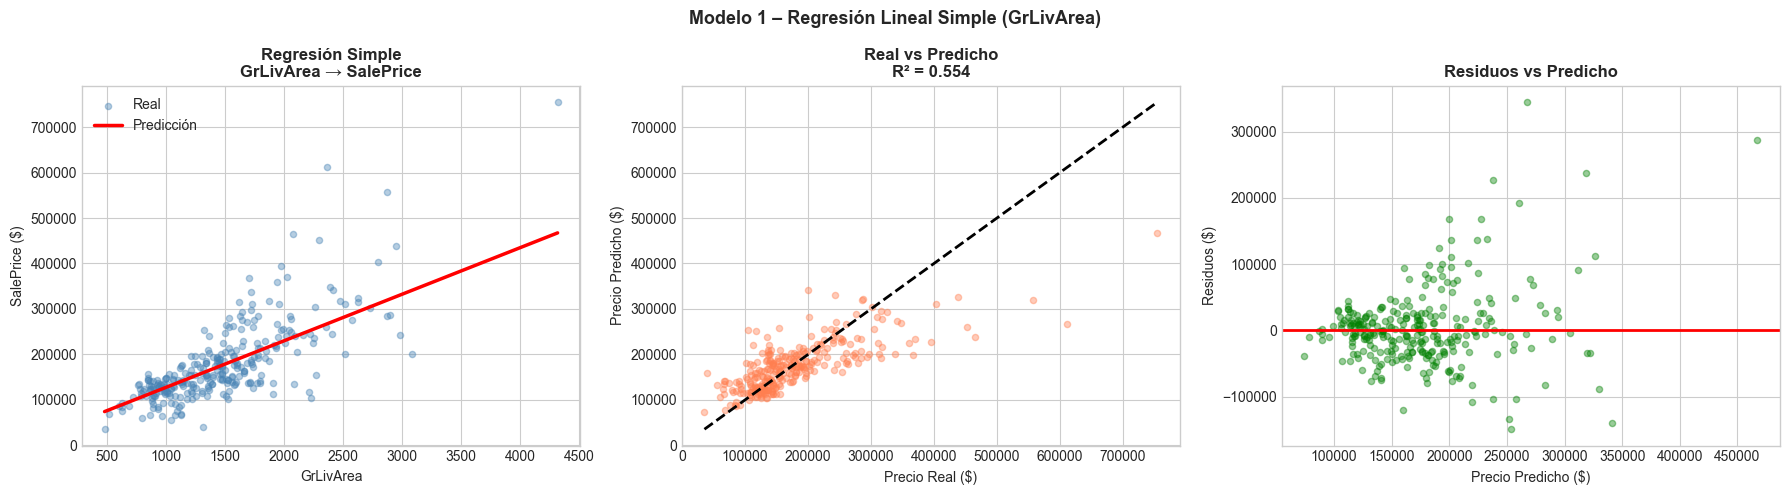

Interpretación Modelo 1:
  - R²=0.554: GrLivArea explica el 55.4% de la variabilidad del precio
  - Los residuos muestran un patrón en abanico → heterocedasticidad
  - Hay valores extremos (outliers) que el modelo no captura bien


In [32]:
# Visualización Modelo 1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter + línea regresión
axes[0].scatter(X_test['GrLivArea'], y_test, alpha=0.4, color='steelblue', s=20, label='Real')
x_line = np.linspace(X_test['GrLivArea'].min(), X_test['GrLivArea'].max(), 200).reshape(-1,1)
axes[0].plot(x_line, model1.predict(x_line), 'r-', linewidth=2.5, label='Predicción')
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice ($)')
axes[0].set_title('Regresión Simple\nGrLivArea → SalePrice', fontweight='bold')
axes[0].legend()

# Predicho vs Real
axes[1].scatter(y_test, y_pred_test_m1, alpha=0.4, color='coral', s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
axes[1].set_xlabel('Precio Real ($)')
axes[1].set_ylabel('Precio Predicho ($)')
axes[1].set_title(f'Real vs Predicho\nR² = {r2_m1_te:.3f}', fontweight='bold')

# Residuos
residuals_m1 = y_test - y_pred_test_m1
axes[2].scatter(y_pred_test_m1, residuals_m1, alpha=0.4, color='green', s=20)
axes[2].axhline(0, color='red', linewidth=2)
axes[2].set_xlabel('Precio Predicho ($)')
axes[2].set_ylabel('Residuos ($)')
axes[2].set_title('Residuos vs Predicho', fontweight='bold')

plt.suptitle('Modelo 1 – Regresión Lineal Simple (GrLivArea)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretación Modelo 1:')
print(f'  - R²={r2_m1_te:.3f}: GrLivArea explica el {r2_m1_te*100:.1f}% de la variabilidad del precio')
print('  - Los residuos muestran un patrón en abanico → heterocedasticidad')
print('  - Hay valores extremos (outliers) que el modelo no captura bien')

---
## Actividad 8 – Modelo con Todas las Variables Numéricas

In [ ]:
# ============================================================
# MODELO 2: Regresión Lineal Múltiple 
# ============================================================
print(f'=== MODELO 2: Regresión Lineal Múltiple ===')
print(f'Variables predictoras: {X_train.shape[1]} (todas las numéricas)\n')

model2 = LinearRegression()
model2.fit(X_train, y_train)

y_pred_train_m2 = model2.predict(X_train)
y_pred_test_m2  = model2.predict(X_test)

r2_m2_tr, rmse_m2_tr, mae_m2_tr = print_metrics(y_train, y_pred_train_m2, 'Modelo 2 – Entrenamiento')
r2_m2_te, rmse_m2_te, mae_m2_te = print_metrics(y_test, y_pred_test_m2, 'Modelo 2 – Prueba      ')

# Statsmodels
X_sm2 = sm.add_constant(X_train)
model2_sm = sm.OLS(y_train, X_sm2).fit()
print('\n', model2_sm.summary())

=== MODELO 2: Regresión Lineal Múltiple ===
Variables predictoras: 36 (todas las numéricas)

Modelo 2 – Entrenamiento: R²=0.8071 | RMSE=$33,920 | MAE=$21,067
Modelo 2 – Prueba      : R²=0.8231 | RMSE=$36,837 | MAE=$22,976

                             OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     139.4
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:47:44   Log-Likelihood:                -13842.
No. Observations:                1168   AIC:                         2.775e+04
Df Residuals:                    1133   BIC:                         2.793e+04
Df Model:                          34                                         
Covariance Type:            nonrobust                            

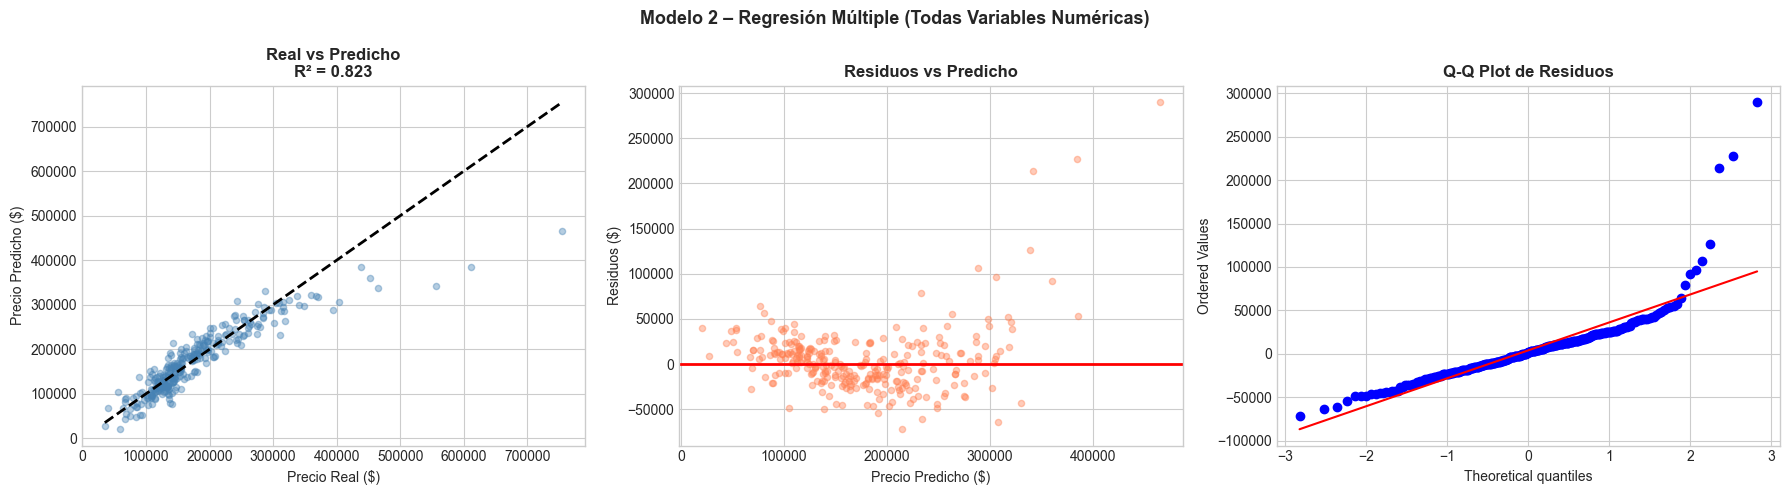

Interpretación Modelo 2:
  - R²=0.823: Mejora significativa sobre el modelo simple
  - Gap entrenamiento/prueba: -0.016
  - Gap pequeño, sobreajuste moderado


In [33]:
# Visualización Modelo 2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_test_m2, alpha=0.4, color='steelblue', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
axes[0].set_xlabel('Precio Real ($)')
axes[0].set_ylabel('Precio Predicho ($)')
axes[0].set_title(f'Real vs Predicho\nR² = {r2_m2_te:.3f}', fontweight='bold')

residuals_m2 = y_test - y_pred_test_m2
axes[1].scatter(y_pred_test_m2, residuals_m2, alpha=0.4, color='coral', s=20)
axes[1].axhline(0, color='red', linewidth=2)
axes[1].set_xlabel('Precio Predicho ($)')
axes[1].set_ylabel('Residuos ($)')
axes[1].set_title('Residuos vs Predicho', fontweight='bold')

stats.probplot(residuals_m2, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot de Residuos', fontweight='bold')

plt.suptitle('Modelo 2 – Regresión Múltiple (Todas Variables Numéricas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretación Modelo 2:')
print(f'  - R²={r2_m2_te:.3f}: Mejora significativa sobre el modelo simple')
overfitting_gap = r2_m2_tr - r2_m2_te
print(f'  - Gap entrenamiento/prueba: {overfitting_gap:.3f}')
if overfitting_gap > 0.05:
    print('  - Posible sobreajuste detectado (gap > 0.05)')
else:
    print('  - Gap pequeño, sobreajuste moderado')